In [1]:
import numpy as np
from scipy import stats
import scipy
import matplotlib.pyplot as plt
import pandas as pd

### Problem 1

In [2]:
df_1 = pd.DataFrame(np.array([[0,3,0,3], [1,1,2,2,],[35,46,42,40]]).T, columns=['Ni', 'Mn', 'Strength'])
df_1

,Ni,Mn,Strength
0,0,1,35
1,3,1,46
2,0,2,42
3,3,2,40


In [3]:
df_1['Strength'].mean()

np.float64(40.75)

In [4]:
df_1.groupby('Ni')['Strength'].mean().diff()

Ni
0    NaN
3    4.5
Name: Strength, dtype: float64

In [5]:
df_1.groupby('Mn')['Strength'].mean().diff()

Mn
1    NaN
2    0.5
Name: Strength, dtype: float64

In [6]:
df_1.groupby(['Ni', 'Mn'])['Strength'].mean().diff(2)

Ni  Mn
0   1      NaN
    2      NaN
3   1     11.0
    2     -2.0
Name: Strength, dtype: float64

In [7]:
df_1.groupby(['Ni', 'Mn'])['Strength'].mean().diff(2).diff(1)/2

Ni  Mn
0   1     NaN
    2     NaN
3   1     NaN
    2    -6.5
Name: Strength, dtype: float64

### Problem 2
assumptions: randomized experiments

In [8]:
df_2 = pd.DataFrame({
    'T': [(-1)**(i+1) for i in range(8)],
    'conc': [(-1)**(i//2+1) for i in range(8)],
    'cat': [(-1)**(i//4+1) for i in range(8)],
    'yield':[60,77,59,68,57,83,45,85],
})

df_2

,T,conc,cat,yield
0,-1,-1,-1,60
1,1,-1,-1,77
2,-1,1,-1,59
3,1,1,-1,68
4,-1,-1,1,57
5,1,-1,1,83
6,-1,1,1,45
7,1,1,1,85


In [9]:
def yates_algor(pd_serie, n):
    '''
    pd_serie: results in the correct order according to Yates algorithm
    n: number of iterations
    '''
    for i in range(n):
        # print(pd_serie)
        index_1 = pd_serie.index[::2]
        index_2 = pd_serie.index[1::2]
        serie_1 = pd_serie[index_1].reset_index(drop=True) + pd_serie[index_2].reset_index(drop=True)
        serie_2 = -pd_serie[index_1].reset_index(drop=True) + pd_serie[index_2].reset_index(drop=True)
        pd_serie = pd.concat((serie_1, serie_2)).reset_index(drop=True)

    pd_serie = pd_serie / pd_serie.shape[0] * 2
    pd_serie.iloc[0] = pd_serie.iloc[0] / 2
    return pd_serie

In [10]:
yates_algor(df_2.iloc[:,3], 3)

0    66.75
1    23.00
2    -5.00
3     1.50
4     1.50
5    10.00
6     0.00
7     5.50
Name: yield, dtype: float64

In [11]:
factors_2 = list(df_2.columns)[:-1]
factors_2

['T', 'conc', 'cat']

In [12]:
from itertools import combinations
factors_2_comb = []
for i in range(1, len(factors_2)):
    factors_2_comb.extend(list(combinations(factors_2, i+1)))

factors_2_comb

[('T', 'conc'), ('T', 'cat'), ('conc', 'cat'), ('T', 'conc', 'cat')]

In [13]:
for j in ([[_] for _ in factors_2] + factors_2_comb):
    print(list(j)+['yield'])
    print(df_2[list(j)+['yield']].prod(axis=1).sum()/4)

['T', 'yield']
23.0
['conc', 'yield']
-5.0
['cat', 'yield']
1.5
['T', 'conc', 'yield']
1.5
['T', 'cat', 'yield']
10.0
['conc', 'cat', 'yield']
0.0
['T', 'conc', 'cat', 'yield']
5.5


### Problem 6


| Code | name | low level | high level|
| -------- | -------- | -------- | --------|
| x1 | time since last bath | 1 hour | 24 hours |
| x2 | vigor of bathing activity | lethargic | vigorous |
| x3 | sex of bather | female | male |


| code | name (organisms per 100 mL) |
| -------- | -------- |
| y1 | fecal coliform contribution after 15 min | 
| y2 | fecal coliform contribution after 30 min | 
| y3 | total coliform contribution after 15 min | 
| y4 | total coliform contribution after 30 min | 

In [14]:
df_6 = pd.DataFrame({
    'run': np.arange(16) + 1,
    'x1': [(-1)**(i+1) for i in range(16)],
    'x2': [(-1)**(i//2 + 1) for i in range(16)],
    'x3': [(-1)**(i//4 + 1) for i in range(16)],
    'y1': [1,12,16,4,153,129,143,113,2,37,21,2,96,390,300,280],
    'y2': [1,15,10,6,170,148,170,217,4,39,21,5,67,360,377,250],
    'y3': [3,57,323,183,426,250,580,650,10,280,33,10,147,1470,665,675],
    'y4': [7,80,360,193,590,243,450,735,27,250,53,87,193,1560,810,795]
})

In [15]:
df_6

,run,x1,x2,x3,y1,y2,y3,y4
0,1,-1,-1,-1,1,1,3,7
1,2,1,-1,-1,12,15,57,80
2,3,-1,1,-1,16,10,323,360
3,4,1,1,-1,4,6,183,193
4,5,-1,-1,1,153,170,426,590
5,6,1,-1,1,129,148,250,243
6,7,-1,1,1,143,170,580,450
7,8,1,1,1,113,217,650,735
8,9,-1,-1,-1,2,4,10,27
9,10,1,-1,-1,37,39,280,250


In [16]:
df_6.iloc[:,-4:].apply(np.log)

,y1,y2,y3,y4
0,0.000000,0.000000,1.098612,1.945910
1,2.484907,2.708050,4.043051,4.382027
2,2.772589,2.302585,5.777652,5.886104
3,1.386294,1.791759,5.209486,5.262690
4,5.030438,5.135798,6.054439,6.380123
5,4.859812,4.997212,5.521461,5.493061
6,4.962845,5.135798,6.363028,6.109248
7,4.727388,5.379897,6.476972,6.599870
8,0.693147,1.386294,2.302585,3.295837
9,3.610918,3.663562,5.634790,5.521461


In [17]:
df_6_log = df_6.copy()
df_6_log = pd.merge(df_6_log.iloc[:,:-4], df_6.iloc[:,-4:].apply(np.log), left_index=True, right_index=True)
df_6_log

,run,x1,x2,x3,y1,y2,y3,y4
0,1,-1,-1,-1,0.000000,0.000000,1.098612,1.945910
1,2,1,-1,-1,2.484907,2.708050,4.043051,4.382027
2,3,-1,1,-1,2.772589,2.302585,5.777652,5.886104
3,4,1,1,-1,1.386294,1.791759,5.209486,5.262690
4,5,-1,-1,1,5.030438,5.135798,6.054439,6.380123
5,6,1,-1,1,4.859812,4.997212,5.521461,5.493061
6,7,-1,1,1,4.962845,5.135798,6.363028,6.109248
7,8,1,1,1,4.727388,5.379897,6.476972,6.599870
8,9,-1,-1,-1,0.693147,1.386294,2.302585,3.295837
9,10,1,-1,-1,3.610918,3.663562,5.634790,5.521461


In [18]:
factors_6 = ['x1', 'x2', 'x3']
results_6 = ['y1', 'y2', 'y3', 'y4']
factors_6_comb = []
from itertools import combinations
for i in range(len(factors_6)):
    factors_6_comb.extend(combinations(factors_6, i+1))
# print(factors_6_comb)
ana_6 = dict()
for j in factors_6_comb:
    ana_6['_'.join(list(j))] = [df_6_log[list(j) + [y]].prod(axis=1).sum()/8 for y in results_6]
    # for y in results_6:
    #     print(list(j) + [y])
    #     print(df_6_log[list(j) + [y]].prod(axis=1).sum()/8)

df_ana_6 = pd.DataFrame(ana_6, index=['y1', 'y2', 'y3', 'y4'])
df_ana_6['ave'] = df_6_log.iloc[:,-4:].sum()/16
df_ana_6

,x1,x2,x3,x1_x2,x1_x3,x2_x3,x1_x2_x3,ave
y1,0.323966,0.214455,3.345503,-1.334496,-0.092286,-0.062440,0.950591,3.508442
y2,0.551943,0.341999,3.210875,-1.080092,-0.207908,0.094399,0.652715,3.668714
y3,0.801629,0.712793,2.481073,-1.209934,-0.327010,-0.214005,0.799749,4.973695
y4,0.776070,0.754492,1.980323,-0.690037,-0.357415,-0.355448,0.507347,5.331440


In [19]:
df_ana_6.iloc[1,:-1].sort_values().values

array([-1.08009228, -0.20790843,  0.09439948,  0.34199915,  0.5519434 ,
        0.65271463,  3.21087477])

In [20]:
np.linspace(0,100,8)[:-1] + 100/14

array([ 7.14285714, 21.42857143, 35.71428571, 50.        , 64.28571429,
       78.57142857, 92.85714286])

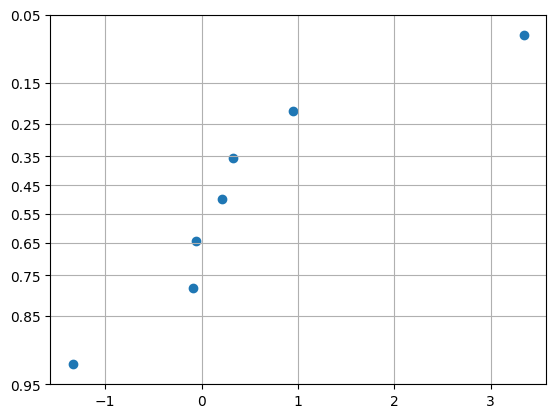

In [21]:
plt.scatter(df_ana_6.iloc[0,:-1].sort_values().values, -stats.norm.isf(np.linspace(0,1,8)[:-1] + 1/14))
plt.yticks(stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))
plt.grid(True)

In [22]:
df_6_log

,run,x1,x2,x3,y1,y2,y3,y4
0,1,-1,-1,-1,0.000000,0.000000,1.098612,1.945910
1,2,1,-1,-1,2.484907,2.708050,4.043051,4.382027
2,3,-1,1,-1,2.772589,2.302585,5.777652,5.886104
3,4,1,1,-1,1.386294,1.791759,5.209486,5.262690
4,5,-1,-1,1,5.030438,5.135798,6.054439,6.380123
5,6,1,-1,1,4.859812,4.997212,5.521461,5.493061
6,7,-1,1,1,4.962845,5.135798,6.363028,6.109248
7,8,1,1,1,4.727388,5.379897,6.476972,6.599870
8,9,-1,-1,-1,0.693147,1.386294,2.302585,3.295837
9,10,1,-1,-1,3.610918,3.663562,5.634790,5.521461


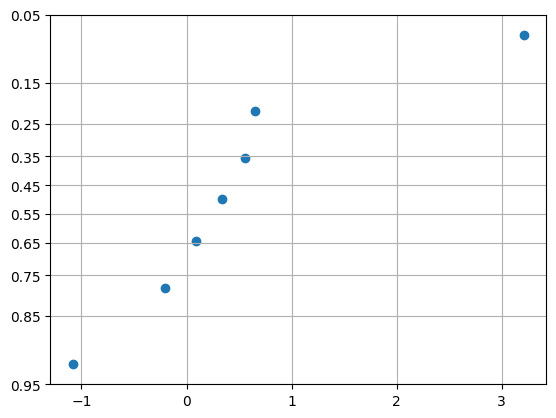

In [23]:
plt.scatter(df_ana_6.iloc[1,:-1].sort_values().values, -stats.norm.isf(np.linspace(0,1,8)[:-1] + 1/14))
plt.yticks(stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))
plt.grid(True)

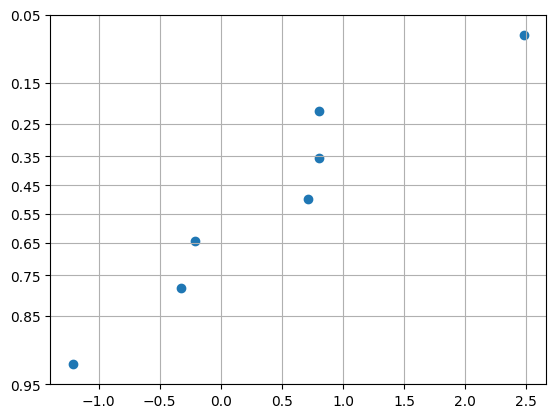

In [24]:
plt.scatter(df_ana_6.iloc[2,:-1].sort_values().values, -stats.norm.isf(np.linspace(0,1,8)[:-1] + 1/14))
plt.yticks(stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))
plt.grid(True)

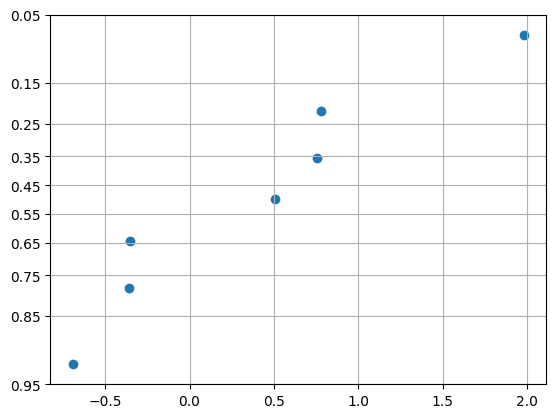

In [25]:
plt.scatter(df_ana_6.iloc[3,:-1].sort_values().values, -stats.norm.isf(np.linspace(0,1,8)[:-1] + 1/14))
plt.yticks(stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))
plt.grid(True)

In [26]:
df_ana_6

,x1,x2,x3,x1_x2,x1_x3,x2_x3,x1_x2_x3,ave
y1,0.323966,0.214455,3.345503,-1.334496,-0.092286,-0.062440,0.950591,3.508442
y2,0.551943,0.341999,3.210875,-1.080092,-0.207908,0.094399,0.652715,3.668714
y3,0.801629,0.712793,2.481073,-1.209934,-0.327010,-0.214005,0.799749,4.973695
y4,0.776070,0.754492,1.980323,-0.690037,-0.357415,-0.355448,0.507347,5.331440


In [27]:
df_ana_6['effect_se'] = np.sqrt((df_ana_6.iloc[:, -4:-2]**2).mean(axis=1)) # estimated standard error of an effect
df_ana_6

,x1,x2,x3,x1_x2,x1_x3,x2_x3,x1_x2_x3,ave,effect_se
y1,0.323966,0.214455,3.345503,-1.334496,-0.092286,-0.062440,0.950591,3.508442,0.078789
y2,0.551943,0.341999,3.210875,-1.080092,-0.207908,0.094399,0.652715,3.668714,0.161458
y3,0.801629,0.712793,2.481073,-1.209934,-0.327010,-0.214005,0.799749,4.973695,0.276346
y4,0.776070,0.754492,1.980323,-0.690037,-0.357415,-0.355448,0.507347,5.331440,0.356433


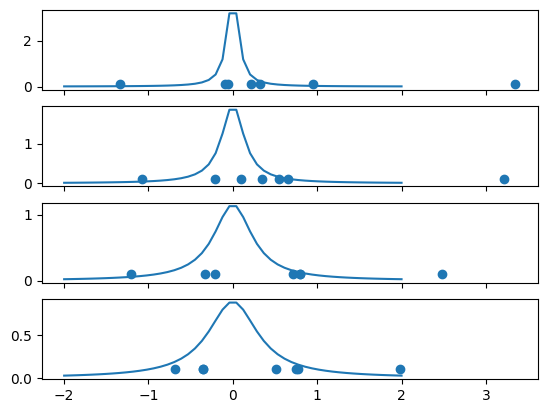

In [28]:
fig, ax = plt.subplots(4,1,sharex=True)
for j in range(4):
    # print(j)
    ax[j].scatter(df_ana_6.iloc[j,:7], [0.1]*7)
    ax[j].plot(np.linspace(-2,2), stats.t.pdf(np.linspace(-2,2),df=1,scale=df_ana_6.iloc[j,8]))


### Problem 7
no significant effects

In [29]:
df_7 = pd.DataFrame({
    'x1': [(-1)**(i+1) for i in range(8)],
    'x2': [(-1)**(i//2+1) for i in range(8)],
    'x3': [(-1)**(i//4+1) for i in range(8)],
    'y': [60,51,54,75,58,61,55,75]
})
df_7

,x1,x2,x3,y
0,-1,-1,-1,60
1,1,-1,-1,51
2,-1,1,-1,54
3,1,1,-1,75
4,-1,-1,1,58
5,1,-1,1,61
6,-1,1,1,55
7,1,1,1,75


In [30]:
effects_7 = yates_algor(df_7['y'],3)

In [31]:
effects_7

0    61.125
1     8.750
2     7.250
3    11.750
4     2.250
5     2.750
6    -1.750
7    -3.250
Name: y, dtype: float64

In [32]:
np.linspace(0,1,8) + 1/14

array([0.07142857, 0.21428571, 0.35714286, 0.5       , 0.64285714,
       0.78571429, 0.92857143, 1.07142857])

In [33]:
effects_7[1:].sort_values()

7    -3.25
6    -1.75
4     2.25
5     2.75
2     7.25
1     8.75
3    11.75
Name: y, dtype: float64

([<matplotlib.axis.YTick at 0x1f5cf390550>,
 [Text(0, -1.6448536269514729, '0.05'),
  Text(0, -1.0364333894937898, '0.15'),
  Text(0, -0.6744897501960817, '0.25'),
  Text(0, -0.38532046640756773, '0.35'),
  Text(0, -0.12566134685507416, '0.45'),
  Text(0, 0.12566134685507388, '0.55'),
  Text(0, 0.38532046640756773, '0.65'),
  Text(0, 0.6744897501960817, '0.75'),
  Text(0, 1.0364333894937898, '0.85'),
  Text(0, 1.6448536269514722, '0.95')])

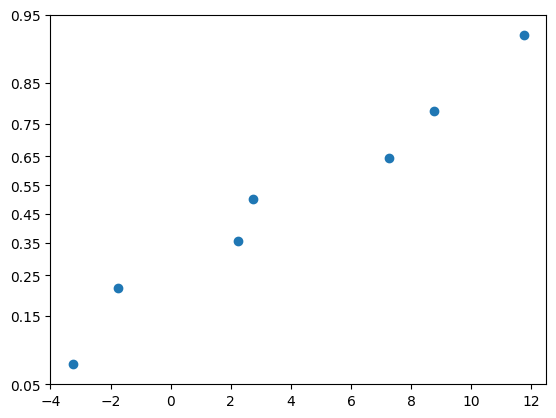

In [34]:
plt.scatter(effects_7[1:].sort_values(), -stats.norm.isf((np.linspace(0,1,8) + 1/14)[:-1]))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))

### Problem 8

In [35]:
df_8 = pd.DataFrame({
        'Temp': [(-1)**(i+1) for i in range(8)],
    'Cat': [(-1)**(i//2+1) for i in range(8)],
    'pH': [(-1)**(i//4+1) for i in range(8)],
'w1': [60.4,75.4,61.2,67.3,66.,82.9,68.1,75.3],
'w2': [62.1,73.1,59.6,66.7,63.3,82.4,71.3,77.1]
})
df_8

,Temp,Cat,pH,w1,w2
0,-1,-1,-1,60.4,62.1
1,1,-1,-1,75.4,73.1
2,-1,1,-1,61.2,59.6
3,1,1,-1,67.3,66.7
4,-1,-1,1,66.0,63.3
5,1,-1,1,82.9,82.4
6,-1,1,1,68.1,71.3
7,1,1,1,75.3,77.1


In [36]:
df_8['yield'] = df_8[['w1', 'w2']].mean(axis=1)

In [37]:
df_8['var'] = df_8[['w1', 'w2']].var(axis=1,ddof=1)

In [38]:
df_8['var'].mean() # pooled estimate of variance from the average of estimated variances

np.float64(2.007500000000005)

In [39]:
effect_var_8 = 4/16*df_8['var'].mean()
effect_se_8 = np.sqrt(effect_var_8)
effect_var_8, effect_se_8

(np.float64(0.5018750000000013), np.float64(0.7084313657652386))

In [40]:
effects_8 = yates_algor(df_8['yield'],3)
effects_8

0    69.5125
1    11.0250
2    -2.3750
3    -4.4750
4     7.5750
5     1.2250
6     1.6750
7    -1.2750
Name: yield, dtype: float64

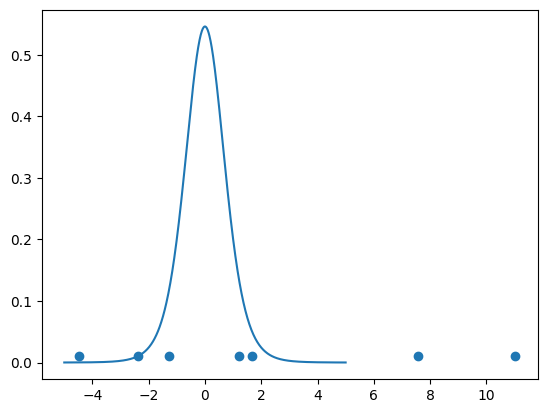

In [41]:
range_8 = 5
plt.scatter(effects_8[1:], [0.01]*7)
plt.plot(np.linspace(-range_8,range_8,1001), stats.t.pdf(np.linspace(-range_8,range_8,1001),df=8,scale=effect_se_8))

([<matplotlib.axis.YTick at 0x1f5ce19da90>,
 [Text(0, -1.6448536269514729, '0.05'),
  Text(0, -1.0364333894937898, '0.15'),
  Text(0, -0.6744897501960817, '0.25'),
  Text(0, -0.38532046640756773, '0.35'),
  Text(0, -0.12566134685507416, '0.45'),
  Text(0, 0.12566134685507388, '0.55'),
  Text(0, 0.38532046640756773, '0.65'),
  Text(0, 0.6744897501960817, '0.75'),
  Text(0, 1.0364333894937898, '0.85'),
  Text(0, 1.6448536269514722, '0.95')])

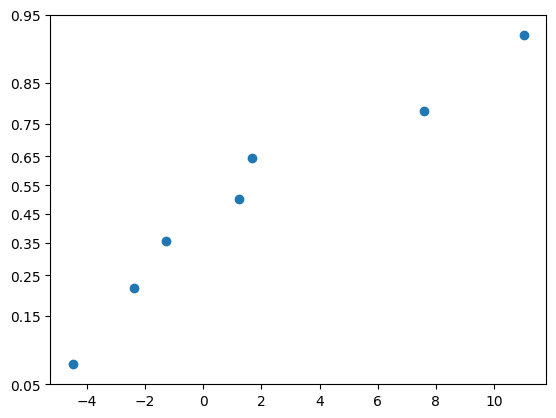

In [42]:
plt.scatter(effects_8[1:].sort_values(), -stats.norm.isf(np.linspace(0,1,8)[:-1]+1/14))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))

Focusing on temperature and pH (increase T and pH)

### Problem 9

In [43]:
df_9 = pd.DataFrame({
    'A': [-1,-1,-1,1,1,1,-1,1],
    'B': [1,-1,-1,-1,-1,1,1,1],
    'C': [1,1,-1,-1,1,1,-1,-1],
    'D': [1,-1,1,-1,1,-1,-1,1],
    'results': [8.2,1.7,6.2,3.0,6.8,5.0,3.8,9.3]
})
df_9

,A,B,C,D,results
0,-1,1,1,1,8.2
1,-1,-1,1,-1,1.7
2,-1,-1,-1,1,6.2
3,1,-1,-1,-1,3.0
4,1,-1,1,1,6.8
5,1,1,1,-1,5.0
6,-1,1,-1,-1,3.8
7,1,1,-1,1,9.3


In [44]:
factors_9 = [i for i in 'ABCD']
combs_9 = []
from itertools import combinations
for i in range(4):
    combs_9.extend(combinations(factors_9,i+1))

combs_9

[('A',),
 ('B',),
 ('C',),
 ('D',),
 ('A', 'B'),
 ('A', 'C'),
 ('A', 'D'),
 ('B', 'C'),
 ('B', 'D'),
 ('C', 'D'),
 ('A', 'B', 'C'),
 ('A', 'B', 'D'),
 ('A', 'C', 'D'),
 ('B', 'C', 'D'),
 ('A', 'B', 'C', 'D')]

In [45]:
effects_9 = dict()
for j in combs_9:
    effects_9[''.join(j)] = df_9[list(j)+['results']].prod(axis=1).sum().round(3)/4
effects_9

{'A': np.float64(1.05),
 'B': np.float64(2.15),
 'C': np.float64(-0.15),
 'D': np.float64(4.25),
 'AB': np.float64(0.1),
 'AC': np.float64(-0.1),
 'AD': np.float64(-0.2),
 'BC': np.float64(0.2),
 'BD': np.float64(0.1),
 'CD': np.float64(-0.1),
 'ABC': np.float64(-4.25),
 'ABD': np.float64(0.15),
 'ACD': np.float64(-2.15),
 'BCD': np.float64(-1.05),
 'ABCD': np.float64(-11.0)}

In [46]:
df_9['results'].mean()

np.float64(5.5)

suggestions: D,B,and A increse the unburned hydrocarbons with decreasing effect. Optimize D, B, and A. C has no effect, and no interactions btw any two factors

### Problem 10

| Symbols | Temperature (C) | Concentration (%) | Stirring rate (rpm) |
| -------- | -------- | -------- | -------- |
| - (-1) | 50 | 6 | 60 |
| + (+1) | 60 | 10 | 100|

In [47]:
df_10 = pd.DataFrame({
    'temp': [(-1)**(i//1+1) for i in range(8)],
    'conc': [(-1)**(i//2+1) for i in range(8)],
    'stir': [(-1)**(i//4+1) for i in range(8)],
    'yield': [54,57,69,70,55,54,80,81]
})
df_10

,temp,conc,stir,yield
0,-1,-1,-1,54
1,1,-1,-1,57
2,-1,1,-1,69
3,1,1,-1,70
4,-1,-1,1,55
5,1,-1,1,54
6,-1,1,1,80
7,1,1,1,81


In [48]:
def get_effects(factors, df, results):
    combs = []
    from itertools import combinations
    for i in range(len(factors)):
        combs.extend(combinations(factors,i+1))
            
    effects = dict()
    for j in combs:
        effects[''.join(j)] = df[list(j)+[results]].prod(axis=1).sum().round(3)/df.shape[0]*2
    
    return effects

In [49]:
get_effects(['temp', 'conc', 'stir'], df_10, 'yield')

{'temp': np.float64(1.0),
 'conc': np.float64(20.0),
 'stir': np.float64(5.0),
 'tempconc': np.float64(0.0),
 'tempstir': np.float64(-1.0),
 'concstir': np.float64(6.0),
 'tempconcstir': np.float64(1.0)}

focus on concentration and stir rates. increase both to increase yield

### Problem 11

In [50]:
# two factors with 4 levels each
f1_11 = [_ for _ in 'ABCD']
f2_11 = [_ for _ in 'abcd']

In [51]:
df_11 = pd.DataFrame({'f1': np.repeat(f1_11,4),
                'f2': np.tile(f2_11, 4)})
df_11

,f1,f2
0,A,a
1,A,b
2,A,c
3,A,d
4,B,a
5,B,b
6,B,c
7,B,d
8,C,a
9,C,b


In [52]:
coords = np.meshgrid([1,2,3,4],
             [1,2,3,4])

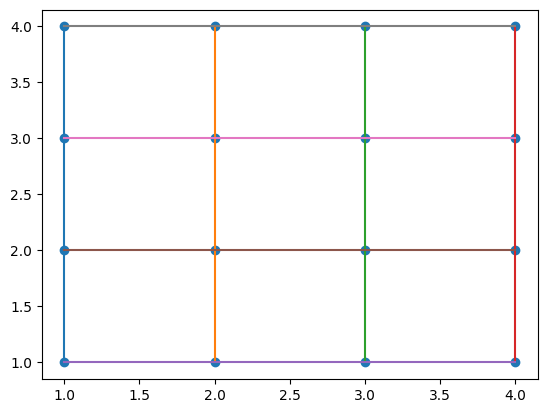

In [53]:
plt.plot(coords[0], coords[1])
plt.plot(coords[1], coords[0])
plt.scatter(coords[0], coords[1])

### Problem 12

In [54]:
df_12 = pd.DataFrame({
    '1': [(-1)**(i//1+1) for i in range(8)],
    '2': [(-1)**(i//2+1) for i in range(8)],
    '3': [(-1)**(i//4+1) for i in range(8)],

})
df_12

,1,2,3
0,-1,-1,-1
1,1,-1,-1
2,-1,1,-1
3,1,1,-1
4,-1,-1,1
5,1,-1,1
6,-1,1,1
7,1,1,1


In [55]:
df_12['B1'] = df_12[['1','2']].prod(axis=1)
df_12['B2'] = df_12[['1', '3']].prod(axis=1)
df_12

,1,2,3,B1,B2
0,-1,-1,-1,1,1
1,1,-1,-1,-1,-1
2,-1,1,-1,-1,1
3,1,1,-1,1,-1
4,-1,-1,1,1,-1
5,1,-1,1,-1,1
6,-1,1,1,-1,-1
7,1,1,1,1,1


In [56]:
df_12.sort_values(['B1', 'B2'])

,1,2,3,B1,B2
1,1,-1,-1,-1,-1
6,-1,1,1,-1,-1
2,-1,1,-1,-1,1
5,1,-1,1,-1,1
3,1,1,-1,1,-1
4,-1,-1,1,1,-1
0,-1,-1,-1,1,1
7,1,1,1,1,1


### Problem 13

In [57]:
pd.DataFrame({
    'filler': np.repeat([5,10,15,20],4),
    'curing': np.tile(np.repeat(['c1', 'c2'],2),4),
    'spreading': np.tile(['s1','s2'],8)
})

,filler,curing,spreading
0,5,c1,s1
1,5,c1,s2
2,5,c2,s1
3,5,c2,s2
4,10,c1,s1
5,10,c1,s2
6,10,c2,s1
7,10,c2,s2
8,15,c1,s1
9,15,c1,s2


### Problem 14

| symbols | relative humidity (rh) | temperature (temp) | pump |
| -------- | -------- | -------- | -------- |
| -1 | 40 | 70 | off |
| +1 | 50 | 95 | on |

In [58]:
df_14 = pd.DataFrame({
    'run': np.arange(8)+1,
    'order': [4,7,1,2,3,6,5,8],
    'rh': [(-1)**(i//1+1) for i in range(8)],
    'temp': [(-1)**(i//2+1) for i in range(8)],
    'pump': [(-1)**(i//4) for i in range(8)],
    'results': [77,67,28,32,75,73,29,28]
})
df_14

,run,order,rh,temp,pump,results
0,1,4,-1,-1,1,77
1,2,7,1,-1,1,67
2,3,1,-1,1,1,28
3,4,2,1,1,1,32
4,5,3,-1,-1,-1,75
5,6,6,1,-1,-1,73
6,7,5,-1,1,-1,29
7,8,8,1,1,-1,28


In [59]:
get_effects(['rh', 'temp', 'pump'], df_14, 'results')

{'rh': np.float64(-2.25),
 'temp': np.float64(-43.75),
 'pump': np.float64(-0.25),
 'rhtemp': np.float64(3.75),
 'rhpump': np.float64(-0.75),
 'temppump': np.float64(1.75),
 'rhtemppump': np.float64(3.25)}

clearly, temperature has the highest effect on the final results. relative humidity might have a little effect. No significant interactions were observed among different factors. 

### Problem 15

In [60]:
df_15 = pd.DataFrame({
    'temp': [(-1)**(i//1+1) for i in range(8)],
    'conc': [(-1)**(i//2+1) for i in range(8)],
    'time': [(-1)**(i//4+1) for i in range(8)],
    'yield_1' : [80,65,69,74,81,84,91,93],
    'yield_2': [62,63,73,80,79,86,93,93],
})
df_15

,temp,conc,time,yield_1,yield_2
0,-1,-1,-1,80,62
1,1,-1,-1,65,63
2,-1,1,-1,69,73
3,1,1,-1,74,80
4,-1,-1,1,81,79
5,1,-1,1,84,86
6,-1,1,1,91,93
7,1,1,1,93,93


In [61]:
df_15['results'] = df_15.iloc[:,-2:].mean(axis=1)

In [62]:
df_15

,temp,conc,time,yield_1,yield_2,results
0,-1,-1,-1,80,62,71.0
1,1,-1,-1,65,63,64.0
2,-1,1,-1,69,73,71.0
3,1,1,-1,74,80,77.0
4,-1,-1,1,81,79,80.0
5,1,-1,1,84,86,85.0
6,-1,1,1,91,93,92.0
7,1,1,1,93,93,93.0


In [63]:
df_15.sort_values(['temp', 'conc', 'time']).diff(4) # clearly the first value of 'yield_1' is a discrepant value

,temp,conc,time,yield_1,yield_2,results
0,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,0.0,0.0,-15.0,1.0,-7.0
5,2.0,0.0,0.0,3.0,7.0,5.0
3,2.0,0.0,0.0,5.0,7.0,6.0
7,2.0,0.0,0.0,2.0,0.0,1.0


In [64]:
df_15_2 = pd.DataFrame({
    'temp': [(-1)**(i//1+1) for i in range(8)] * 2,
    'conc': [(-1)**(i//2+1) for i in range(8)] * 2,
    'time': [(-1)**(i//4+1) for i in range(8)] * 2,
    'results' : [80,65,69,74,81,84,91,93] + [62,63,73,80,79,86,93,93],
})
df_15_2

,temp,conc,time,results
0,-1,-1,-1,80
1,1,-1,-1,65
2,-1,1,-1,69
3,1,1,-1,74
4,-1,-1,1,81
5,1,-1,1,84
6,-1,1,1,91
7,1,1,1,93
8,-1,-1,-1,62
9,1,-1,-1,63


In [65]:
df_15_2.sort_values(['temp', 'conc', 'time']).diff(8)

,temp,conc,time,results
0,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
12,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
14,NaN,NaN,NaN,NaN
1,2.0,0.0,0.0,-15.0
9,2.0,0.0,0.0,1.0


In [66]:
df_15_2['ave'] = df_15_2['results'].mean()
df_15_2['b_ave'] = df_15_2.groupby(['temp','conc','time'])['results'].transform('mean')
df_15_2['residuals'] = df_15_2['results'] - df_15_2['b_ave']
df_15_2

,temp,conc,time,results,ave,b_ave,residuals
0,-1,-1,-1,80,79.125,71.0,9.0
1,1,-1,-1,65,79.125,64.0,1.0
2,-1,1,-1,69,79.125,71.0,-2.0
3,1,1,-1,74,79.125,77.0,-3.0
4,-1,-1,1,81,79.125,80.0,1.0
5,1,-1,1,84,79.125,85.0,-1.0
6,-1,1,1,91,79.125,92.0,-1.0
7,1,1,1,93,79.125,93.0,0.0
8,-1,-1,-1,62,79.125,71.0,-9.0
9,1,-1,-1,63,79.125,64.0,-1.0


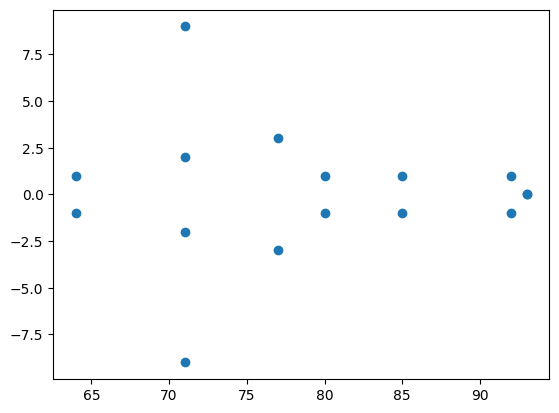

In [67]:
plt.scatter(df_15_2['b_ave'], df_15_2['residuals'])

In [68]:
df_15_2['residual_squares'] = df_15_2['residuals'] ** 2 #
df_15_2['b_var'] = df_15_2.groupby(['temp','conc','time'])['results'].transform(lambda x: np.var(x, ddof=1))
df_15_2

,temp,conc,time,results,ave,b_ave,residuals,residual_squares,b_var
0,-1,-1,-1,80,79.125,71.0,9.0,81.0,162.0
1,1,-1,-1,65,79.125,64.0,1.0,1.0,2.0
2,-1,1,-1,69,79.125,71.0,-2.0,4.0,8.0
3,1,1,-1,74,79.125,77.0,-3.0,9.0,18.0
4,-1,-1,1,81,79.125,80.0,1.0,1.0,2.0
5,1,-1,1,84,79.125,85.0,-1.0,1.0,2.0
6,-1,1,1,91,79.125,92.0,-1.0,1.0,2.0
7,1,1,1,93,79.125,93.0,0.0,0.0,0.0
8,-1,-1,-1,62,79.125,71.0,-9.0,81.0,162.0
9,1,-1,-1,63,79.125,64.0,-1.0,1.0,2.0


In [69]:
# pooled estimate of var of the experiments
s2_15_2 = df_15_2['b_var'].mean()
# effect var
effect_var_15_2 = s2_15_2 * 4 / 16
# effect standard error
effect_se_15_2 = np.sqrt(effect_var_15_2)
effect_se_15_2


np.float64(2.4748737341529163)

In [70]:
effects_15_2 = get_effects(['temp','conc','time'], df_15_2, 'results') # time and concentration have the highest effects
effects_15_2

{'temp': np.float64(1.25),
 'conc': np.float64(8.25),
 'time': np.float64(16.75),
 'tempconc': np.float64(2.25),
 'temptime': np.float64(1.75),
 'conctime': np.float64(1.75),
 'tempconctime': np.float64(-4.25)}

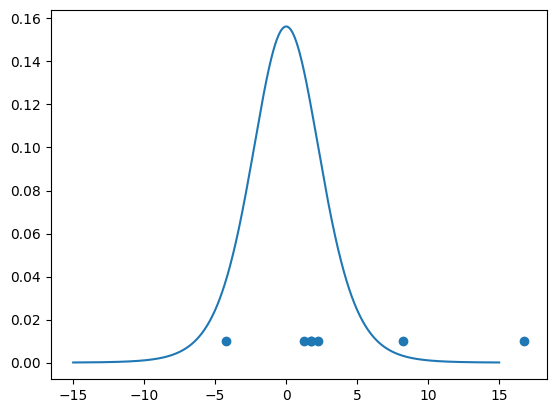

In [71]:
range_15_2 = 15
plt.scatter(effects_15_2.values(), [0.01]*7)
plt.plot(np.linspace(-range_15_2, range_15_2, 1001), stats.t.pdf(np.linspace(-range_15_2, range_15_2, 1001), df=8, scale=effect_se_15_2))

In [72]:
df_15_2_new = pd.DataFrame({
    'temp': [(-1)**(i//1+1) for i in range(8)] * 2,
    'conc': [(-1)**(i//2+1) for i in range(8)] * 2,
    'time': [(-1)**(i//4+1) for i in range(8)] * 2,
    'results' : [np.nan,65,69,74,81,84,91,93] + [62,63,73,80,79,86,93,93],
})
df_15_2_new

,temp,conc,time,results
0,-1,-1,-1,NaN
1,1,-1,-1,65.0
2,-1,1,-1,69.0
3,1,1,-1,74.0
4,-1,-1,1,81.0
5,1,-1,1,84.0
6,-1,1,1,91.0
7,1,1,1,93.0
8,-1,-1,-1,62.0
9,1,-1,-1,63.0


In [73]:
df_15_2_new['ave'] = df_15_2_new['results'].mean()
df_15_2_new['b_ave'] = df_15_2_new.groupby(['temp','conc','time'])['results'].transform('mean')
df_15_2_new['residuals'] = df_15_2_new['results'] - df_15_2_new['b_ave']
df_15_2_new

,temp,conc,time,results,ave,b_ave,residuals
0,-1,-1,-1,NaN,79.066667,62.0,NaN
1,1,-1,-1,65.0,79.066667,64.0,1.0
2,-1,1,-1,69.0,79.066667,71.0,-2.0
3,1,1,-1,74.0,79.066667,77.0,-3.0
4,-1,-1,1,81.0,79.066667,80.0,1.0
5,1,-1,1,84.0,79.066667,85.0,-1.0
6,-1,1,1,91.0,79.066667,92.0,-1.0
7,1,1,1,93.0,79.066667,93.0,0.0
8,-1,-1,-1,62.0,79.066667,62.0,0.0
9,1,-1,-1,63.0,79.066667,64.0,-1.0


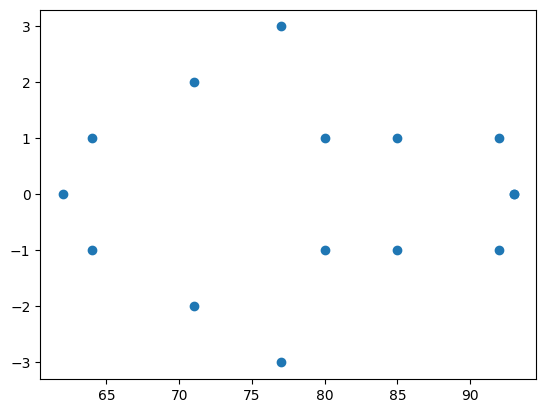

In [74]:
plt.scatter(df_15_2_new['b_ave'], df_15_2_new['residuals'])

In [75]:
df_15_2_new['residual_squares'] = df_15_2_new['residuals'] ** 2 #
df_15_2_new['b_var'] = df_15_2_new.groupby(['temp','conc','time'])['results'].transform(lambda x: np.var(x, ddof=1))
df_15_2_new

,temp,conc,time,results,ave,b_ave,residuals,residual_squares,b_var
0,-1,-1,-1,NaN,79.066667,62.0,NaN,NaN,NaN
1,1,-1,-1,65.0,79.066667,64.0,1.0,1.0,2.0
2,-1,1,-1,69.0,79.066667,71.0,-2.0,4.0,8.0
3,1,1,-1,74.0,79.066667,77.0,-3.0,9.0,18.0
4,-1,-1,1,81.0,79.066667,80.0,1.0,1.0,2.0
5,1,-1,1,84.0,79.066667,85.0,-1.0,1.0,2.0
6,-1,1,1,91.0,79.066667,92.0,-1.0,1.0,2.0
7,1,1,1,93.0,79.066667,93.0,0.0,0.0,0.0
8,-1,-1,-1,62.0,79.066667,62.0,0.0,0.0,NaN
9,1,-1,-1,63.0,79.066667,64.0,-1.0,1.0,2.0


In [76]:
# pooled estimate of var of the experiments
s2_15_2_new = df_15_2_new['b_var'].mean()
# print(s2_15_2_new)
# effect var
effect_var_15_2_new = s2_15_2_new * 4 / 14
# effect standard error
effect_se_15_2_new = np.sqrt(effect_var_15_2_new)
effect_se_15_2_new


np.float64(1.178030178747903)

In [77]:
effects_15_2_new = get_effects(['temp','conc','time'], df_15_2_new, 'results') # time and concentration have the highest effects
effects_15_2_new

{'temp': np.float64(11.125),
 'conc': np.float64(18.125),
 'time': np.float64(26.625),
 'tempconc': np.float64(-7.625),
 'temptime': np.float64(-8.125),
 'conctime': np.float64(-8.125),
 'tempconctime': np.float64(5.625)}

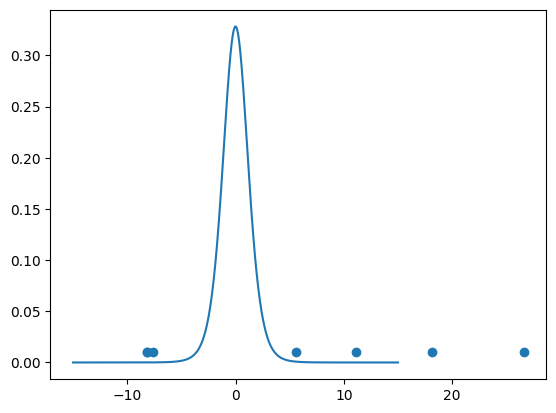

In [78]:
range_15_2_new = 15
plt.scatter(effects_15_2_new.values(), [0.01]*7)
plt.plot(np.linspace(-range_15_2_new, range_15_2_new, 1001), stats.t.pdf(np.linspace(-range_15_2_new, range_15_2_new, 1001), df=8, scale=effect_se_15_2_new))

#### with the discrepant value, only conc and time show significant effect. if omitting the discrepant value, all effects are significant.

### Problem 16

In [79]:
df_16 = pd.DataFrame({
    '1': [-(-1)**(i//8+1) for i in range(16)]+[0],
    '2': [-(-1)**(i//4+1) for i in range(16)]+[0],
    '3': [-(-1)**(i//2+1) for i in range(16)]+[0],
    '4': [-(-1)**(i//1+1) for i in range(16)]+[0],
    'y1': [41.6,39.9,51.9,43,39.2,37.5,50.2,41.3,41.3,39.7,52.4,44.9,38.4,35,51.3,43.5,45.3],
    'y2': [100.,68.6,89.8,82.2,100.,66.,86.3,82.,100.,67.7,84.1,82.1,100.,61.7,83.7,82.,88.9]
    })
df_16

,1,2,3,4,y1,y2
0,1,1,1,1,41.6,100.0
1,1,1,1,-1,39.9,68.6
2,1,1,-1,1,51.9,89.8
3,1,1,-1,-1,43.0,82.2
4,1,-1,1,1,39.2,100.0
5,1,-1,1,-1,37.5,66.0
6,1,-1,-1,1,50.2,86.3
7,1,-1,-1,-1,41.3,82.0
8,-1,1,1,1,41.3,100.0
9,-1,1,1,-1,39.7,67.7


In [80]:
mask_16 = df_16['1'] == 0

In [81]:
df_16[mask_16]

,1,2,3,4,y1,y2
16,0,0,0,0,45.3,88.9


In [82]:
df_16[~mask_16].mean(axis=0)

1      0.00000
2      0.00000
3      0.00000
4      0.00000
y1    43.19375
y2    83.51250
dtype: float64

In [83]:
df_16[~mask_16].std(axis=0,ddof=1)

1      1.032796
2      1.032796
3      1.032796
4      1.032796
y1     5.475091
y2    12.644412
dtype: float64

In [84]:
stats.t.sf(45.3, loc=43.2, scale=5.4751, df=15), stats.t.sf(88.9, loc=83.5, scale=12.6444, df=15)

(np.float64(0.3533451154266768), np.float64(0.3376987857719985))

In [85]:
get_effects([_ for _ in '1234'], df_16[~mask_16], 'y1')

{'1': np.float64(-0.2375),
 '2': np.float64(2.2875),
 '3': np.float64(-8.2375),
 '4': np.float64(5.1875),
 '12': np.float64(-0.2375),
 '13': np.float64(1.1875),
 '14': np.float64(0.1125),
 '23': np.float64(0.8125),
 '24': np.float64(-0.2625),
 '34': np.float64(-3.0875),
 '123': np.float64(-0.4625),
 '124': np.float64(0.2625),
 '134': np.float64(-0.5125),
 '234': np.float64(-0.1875),
 '1234': np.float64(0.1875)}

In [86]:
effects_16_1 = pd.DataFrame(get_effects([_ for _ in '1234'], df_16[~mask_16], 'y1'),index=['effects']).T.sort_values('effects')

In [87]:
effects_16_1

,effects
3,-8.2375
34,-3.0875
134,-0.5125
123,-0.4625
24,-0.2625
1,-0.2375
12,-0.2375
234,-0.1875
14,0.1125
1234,0.1875


In [88]:
ys_ptc_16 = np.linspace(0,1,16)[:-1]+1/30
ys_norm_16 = -stats.norm.isf(ys_ptc_16)
ys_ptc_16, ys_norm_16

(array([0.03333333, 0.1       , 0.16666667, 0.23333333, 0.3       ,
        0.36666667, 0.43333333, 0.5       , 0.56666667, 0.63333333,
        0.7       , 0.76666667, 0.83333333, 0.9       , 0.96666667]),
 array([-1.83391464, -1.28155157, -0.96742157, -0.72791329, -0.52440051,
        -0.34069483, -0.167894  , -0.        ,  0.167894  ,  0.34069483,
         0.52440051,  0.72791329,  0.96742157,  1.28155157,  1.83391464]))

[Text(-8.2375, -1.8339146358159146, '3'),
 Text(-3.0875, -1.2815515655446004, '34'),
 Text(-0.5125, -0.967421566101701, '134'),
 Text(-0.4625, -0.7279132908816442, '123'),
 Text(-0.2625, -0.5244005127080409, '24'),
 Text(-0.2375, -0.3406948270877956, '1'),
 Text(-0.2375, -0.16789400478810546, '12'),
 Text(-0.1875, -0.0, '234'),
 Text(0.1125, 0.16789400478810546, '14'),
 Text(0.1875, 0.3406948270877954, '1234'),
 Text(0.2625, 0.5244005127080407, '124'),
 Text(0.8125, 0.7279132908816441, '23'),
 Text(1.1875, 0.967421566101701, '13'),
 Text(2.2875, 1.2815515655446004, '2'),
 Text(5.1875, 1.8339146358159146, '4')]

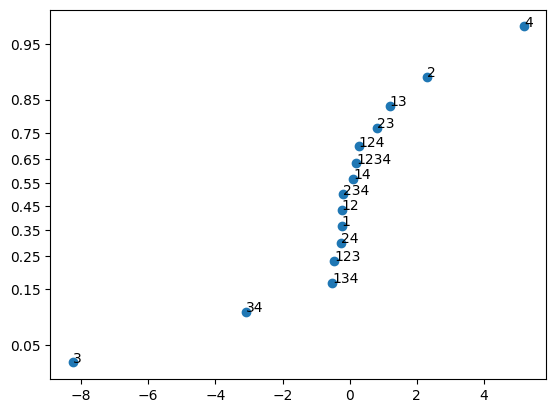

In [89]:
plt.scatter(effects_16_1.effects, ys_norm_16)
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(3))
[plt.text(x,y,s) for x,y,s in zip(effects_16_1.effects, ys_norm_16, effects_16_1.index)]

In [90]:
effects_16_2 = pd.DataFrame(get_effects([_ for _ in '1234'], df_16[~mask_16], 'y2'),index=['effects']).T.sort_values('effects')
effects_16_2

,effects
134,-1.675
234,-1.525
3,-1.025
123,-0.825
24,-0.625
13,-0.400
12,-0.025
1234,0.050
14,0.375
23,0.550


[Text(-1.675, -1.8339146358159146, '134'),
 Text(-1.525, -1.2815515655446004, '234'),
 Text(-1.025, -0.967421566101701, '3'),
 Text(-0.825, -0.7279132908816442, '123'),
 Text(-0.625, -0.5244005127080409, '24'),
 Text(-0.4, -0.3406948270877956, '13'),
 Text(-0.025, -0.16789400478810546, '12'),
 Text(0.05, -0.0, '1234'),
 Text(0.375, 0.16789400478810546, '14'),
 Text(0.55, 0.3406948270877954, '23'),
 Text(0.8, 0.5244005127080407, '124'),
 Text(1.6, 0.7279132908816441, '2'),
 Text(1.7, 0.967421566101701, '1'),
 Text(15.05, 1.2815515655446004, '34'),
 Text(18.95, 1.8339146358159146, '4')]

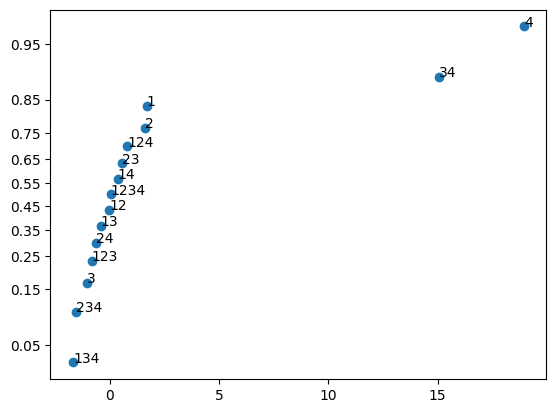

In [91]:
plt.scatter(effects_16_2.effects, ys_norm_16)
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(3))
[plt.text(x,y,s) for x,y,s in zip(effects_16_2.effects, ys_norm_16, effects_16_2.index)]

In [92]:
df_16.groupby('3')[['y1', 'y2']].mean()

,y1,y2
3,,
-1,47.3125,84.025
0,45.3000,88.900
1,39.0750,83.000


so increase factor 4 to increase both efficiencies

### Problem 17
2^(14-9) design

### Problem 18

In [93]:
df_18 = pd.DataFrame({
    '1': [(-1)**(i//1+1) for i in range(8)],
    '2': [(-1)**(i//2+1) for i in range(8)],
    '3': [(-1)**(i//4+1) for i in range(8)],
    'y_bar': [7.76,10.13,5.86,8.76,9.03,14.59,9.18,13.04],
    'std': [0.53,0.74,0.47,1.24,1.12,3.22,1.80,2.58]
})
df_18

,1,2,3,y_bar,std
0,-1,-1,-1,7.76,0.53
1,1,-1,-1,10.13,0.74
2,-1,1,-1,5.86,0.47
3,1,1,-1,8.76,1.24
4,-1,-1,1,9.03,1.12
5,1,-1,1,14.59,3.22
6,-1,1,1,9.18,1.80
7,1,1,1,13.04,2.58


<Axes: xlabel='y_bar', ylabel='std'>

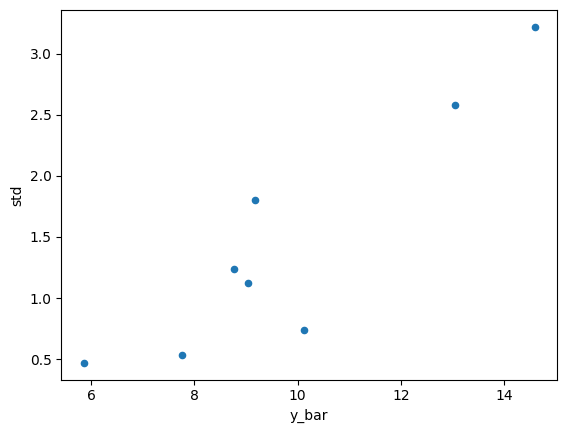

In [94]:
df_18.plot.scatter(x='y_bar', y='std') # transformation is required

In [95]:
effects_18 = get_effects([_ for _ in '123'], df_18, 'y_bar')
effects_18 = pd.DataFrame({'factor': effects_18.keys(), 'effect': effects_18.values()})

effects_18

,factor,effect
0,1,3.6725
1,2,-1.1675
2,3,3.3325
3,12,-0.2925
4,13,1.0375
5,23,0.4675
6,123,-0.5575


In [96]:
s2_18 = (df_18['std']**2).mean() # degree of freedom = 8
se_18 = np.sqrt(s2_18)
se_18

np.float64(1.7358787400046123)

In [97]:
effects_18['p_value'] = effects_18['effect'].transform(lambda x: stats.t.sf(x, scale=se_18, df=8))
effects_18

,factor,effect,p_value
0,1,3.6725,0.033640
1,2,-1.1675,0.739915
2,3,3.3325,0.045573
3,12,-0.2925,0.564815
4,13,1.0375,0.283292
5,23,0.4675,0.397251
6,123,-0.5575,0.621842


transform data and run it again

In [98]:
df_18['log_std'] = np.log(1+df_18['std']**2/df_18['y_bar']**2)

In [99]:
df_18['log_y_bar'] = np.log(df_18['y_bar']) - df_18['log_std']**2/2

<Axes: xlabel='log_y_bar', ylabel='log_std'>

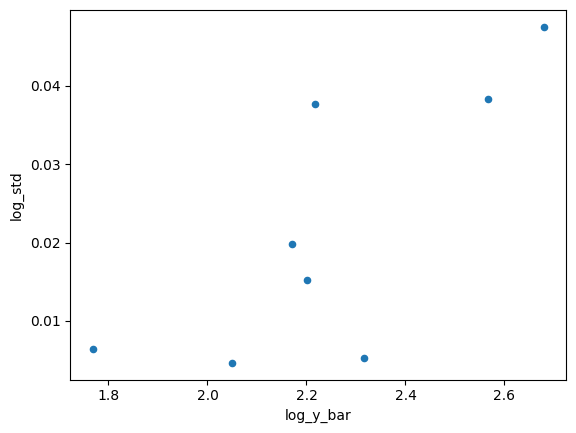

In [100]:
df_18.plot.scatter(x='log_y_bar', y='log_std')

In [101]:
np.polyfit(np.log(df_18['y_bar']), np.log(df_18['std']), 1)

array([ 2.16313205, -4.69080293])

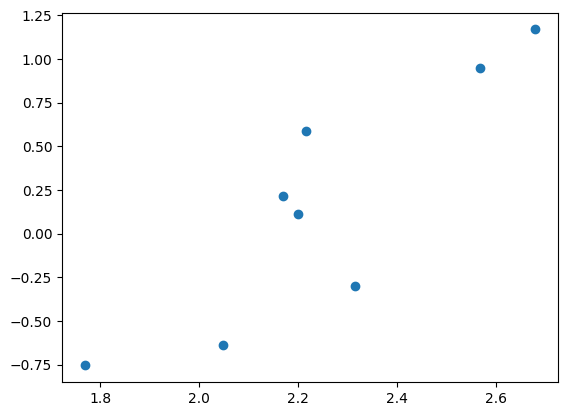

In [102]:
plt.scatter(np.log(df_18['y_bar']), np.log(df_18['std']))

In [103]:
df_18['recip_std'] = df_18['std']/df_18['y_bar']**2
df_18['recip_y_bar'] = 1/df_18['y_bar'] + df_18['std']**2/df_18['y_bar']**3
df_18

,1,2,3,y_bar,std,log_std,log_y_bar,recip_std,recip_y_bar
0,-1,-1,-1,7.76,0.53,0.004654,2.048972,0.008801,0.129467
1,1,-1,-1,10.13,0.74,0.005322,2.315487,0.007211,0.099243
2,-1,1,-1,5.86,0.47,0.006412,1.768129,0.013687,0.171746
3,1,1,-1,8.76,1.24,0.019839,2.169999,0.016159,0.116443
4,-1,-1,1,9.03,1.12,0.015267,2.200436,0.013735,0.112446
5,1,-1,1,14.59,3.22,0.047559,2.679205,0.015127,0.071879
6,-1,1,1,9.18,1.80,0.037726,2.216316,0.021359,0.113121
7,1,1,1,13.04,2.58,0.038399,2.567284,0.015173,0.079689


<Axes: xlabel='recip_y_bar', ylabel='recip_std'>

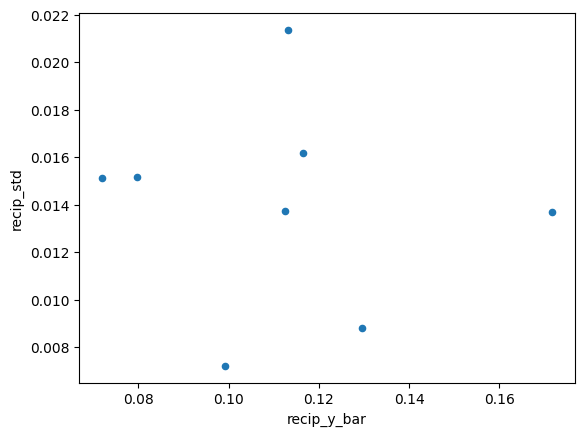

In [104]:
df_18.plot.scatter(x='recip_y_bar', y='recip_std')

In [105]:
effects_18_recip = get_effects([_ for _ in '123'], df_18, 'recip_y_bar')
effects_18_recip = pd.DataFrame({'factor': effects_18_recip.keys(), 'effect': effects_18_recip.values()})

effects_18_recip

,factor,effect
0,1,-0.04000
1,2,0.01700
2,3,-0.03500
3,12,-0.00450
4,13,0.00300
5,23,-0.01275
6,123,0.00800


In [106]:
s2_18_recip = (df_18['recip_std']**2).mean() # degree of freedom = 8
se_18_recip = np.sqrt(s2_18_recip)
se_18_recip

np.float64(0.014499231593367749)

In [107]:
effects_18_recip['p_value'] = effects_18_recip['effect'].transform(lambda x: stats.t.sf(np.abs(x), scale=se_18_recip, df=8))


In [108]:
effects_18_recip

,factor,effect,p_value
0,1,-0.04000,0.012361
1,2,0.01700,0.137367
2,3,-0.03500,0.021124
3,12,-0.00450,0.382109
4,13,0.00300,0.420626
5,23,-0.01275,0.202423
6,123,0.00800,0.298094


the results are the same with the original and the transformed data. Note that the negative effect from the transformed data (transformed by 1/x) mean positive effect of the original data.

### Problem 19

In [109]:
df_19 = pd.DataFrame({
    '1': [(-1)**(i//1+1) for i in range(8)],
    '2': [(-1)**(i//2+1) for i in range(8)],
    '3': [(-1)**(i//4+1) for i in range(8)],
    'y1': [0.312,0.391,0.412,0.376,0.479,0.481,0.465,0.451],
    'y2': [0.448,0.242,0.434,0.251,0.639,0.583,0.657,0.768],
    'y3': [0.576,0.309,0.280,0.201,0.656,0.631,0.736,0.814],
    'y4': [0.326,0.323,0.481,0.312,0.679,0.648,0.680,0.799],
})
df_19

,1,2,3,y1,y2,y3,y4
0,-1,-1,-1,0.312,0.448,0.576,0.326
1,1,-1,-1,0.391,0.242,0.309,0.323
2,-1,1,-1,0.412,0.434,0.280,0.481
3,1,1,-1,0.376,0.251,0.201,0.312
4,-1,-1,1,0.479,0.639,0.656,0.679
5,1,-1,1,0.481,0.583,0.631,0.648
6,-1,1,1,0.465,0.657,0.736,0.680
7,1,1,1,0.451,0.768,0.814,0.799


In [110]:
effects_19 = pd.DataFrame()
for result in df_19.columns[-4:]:
    effects = get_effects([_ for _ in '123'], df_19, result)
    effects_19[result] = effects.values()
    effects_19[result+'_p_value'] = stats.t.sf(np.abs(effects_19[result]), scale=np.sqrt(0.003821), df=18).round(3)

effects_19

,y1,y1_p_value,y2,y2_p_value,y3,y3_p_value,y4,y4_p_value
0,0.00775,0.451,-0.0835,0.097,-0.07325,0.126,-0.021,0.369
1,0.01025,0.435,0.0495,0.217,-0.03525,0.288,0.074,0.123
2,0.09625,0.068,0.3180,0.000,0.36775,0.000,0.341,0.000
3,-0.03275,0.301,0.0475,0.226,0.07275,0.127,-0.004,0.475
4,-0.01375,0.413,0.1110,0.045,0.09975,0.062,0.065,0.153
5,-0.03225,0.304,0.0520,0.206,0.16675,0.007,0.002,0.487
6,0.02475,0.347,0.0360,0.284,-0.02125,0.368,0.079,0.109


### Problem 20
| Symbol | Chemical brand | Temperature (F) | Stirring |
| -------- | -------- | -------- | -------- |
| -1 | A | 72 | none |
| +1 | B | 100 | fast |
| 0 | AB | 86 | intermediate |

In [111]:
df_20 = pd.DataFrame({
    'run_order': [5,6,1,9,11,4,2,7,3,8,10],
    'brand': [(-1)**(i//1+1) for i in range(8)]+[0]*3,
    'temp': [(-1)**(i//2+1) for i in range(8)]+[0]*3,
    'stirring': [(-1)**(i//4+1) for i in range(8)]+[0]*3,
    'pollutant': [5,30,6,33,4,3,5,4,7,4,3]
})
df_20

,run_order,brand,temp,stirring,pollutant
0,5,-1,-1,-1,5
1,6,1,-1,-1,30
2,1,-1,1,-1,6
3,9,1,1,-1,33
4,11,-1,-1,1,4
5,4,1,-1,1,3
6,2,-1,1,1,5
7,7,1,1,1,4
8,3,0,0,0,7
9,8,0,0,0,4


In [112]:
df_20_doe = df_20.iloc[:8]
df_20_center = df_20.iloc[8:]

In [113]:
se_20 = df_20_center['pollutant'].std(ddof=1)
se_20

np.float64(2.0816659994661326)

In [114]:
effects_20 = get_effects(['brand', 'temp', 'stirring'], df_20_doe, 'pollutant')
effects_20 = pd.DataFrame({'factor': effects_20.keys(), 'effect': effects_20.values()})

effects_20

,factor,effect
0,brand,12.5
1,temp,1.5
2,stirring,-14.5
3,brandtemp,0.5
4,brandstirring,-13.5
5,tempstirring,-0.5
6,brandtempstirring,-0.5


In [115]:
effects_20['p_value'] = stats.t.sf(np.abs(effects_20['effect']), scale=se_20, df=2)
effects_20

,factor,effect,p_value
0,brand,12.5,0.013315
1,temp,1.5,0.273005
2,stirring,-14.5,0.009997
3,brandtemp,0.5,0.416278
4,brandstirring,-13.5,0.011481
5,tempstirring,-0.5,0.416278
6,brandtempstirring,-0.5,0.416278


use brand B, high strring rate, interaction matters

### Problem 21
| symbol | concentration of catalyst (1) | concentration of NaOH (2) | agitation (rpm) (3) | temperature (F) (4) |
| - |- |- |- |- |
| -1 | 5 | 40 | 10 | 150 |
| +1 | 7 | 45 | 20 | 180 |

In [116]:
df_21 = pd.DataFrame({
    'run_order': [2,6,12,4,1,7,14,3,8,10,15,11,16,9,5,13],
        '1': [(-1)**(i//1+1) for i in range(16)],
    '2': [(-1)**(i//2+1) for i in range(16)],
    '3': [(-1)**(i//4+1) for i in range(16)],
    '4': [(-1)**(i//8+1) for i in range(16)],
    'impurity': [0.38,0.40,0.27,0.30,0.58,0.56,0.30,0.32,0.59,0.62,0.53,0.50,0.79,0.75,0.53,0.54]
    
})
df_21

,run_order,1,2,3,4,impurity
0,2,-1,-1,-1,-1,0.38
1,6,1,-1,-1,-1,0.40
2,12,-1,1,-1,-1,0.27
3,4,1,1,-1,-1,0.30
4,1,-1,-1,1,-1,0.58
5,7,1,-1,1,-1,0.56
6,14,-1,1,1,-1,0.30
7,3,1,1,1,-1,0.32
8,8,-1,-1,-1,1,0.59
9,10,1,-1,-1,1,0.62


In [117]:
effects_21 = get_effects([_ for _ in '1234'], df_21, 'impurity')
effects_21 = pd.DataFrame({
    'factor': effects_21.keys(),
    'effect': effects_21.values()
})
effects_21

,factor,effect
0,1,0.0025
1,2,-0.1725
2,3,0.0975
3,4,0.2175
4,12,0.0050
5,13,-0.0100
6,14,-0.0100
7,23,-0.0750
8,24,0.0100
9,34,-0.0050


In [118]:
s2_21 = (effects_21[effects_21['factor'].astype(int)>34]['effect']**2).mean() # degree of freedom 5
s2_21

np.float64(9.5e-05)

In [119]:
effects_s2_21 = 4 * s2_21 / 16
effects_se_21 = np.sqrt(effects_s2_21)
effects_se_21

np.float64(0.004873397172404482)

In [120]:
effects_21['p_value'] = stats.t.sf(np.abs(effects_21['effect']), scale=effects_se_21, df=5).round(2)
effects_21

,factor,effect,p_value
0,1,0.0025,0.31
1,2,-0.1725,0.00
2,3,0.0975,0.00
3,4,0.2175,0.00
4,12,0.0050,0.18
5,13,-0.0100,0.05
6,14,-0.0100,0.05
7,23,-0.0750,0.00
8,24,0.0100,0.05
9,34,-0.0050,0.18


In [121]:
effects_21.sort_values('effect')

,factor,effect,p_value
1,2,-0.1725,0.00
7,23,-0.0750,0.00
5,13,-0.0100,0.05
6,14,-0.0100,0.05
11,124,-0.0075,0.09
9,34,-0.0050,0.18
0,1,0.0025,0.31
13,234,0.0025,0.31
12,134,0.0025,0.31
4,12,0.0050,0.18


In [122]:
norm_y_21_pct = np.linspace(0,1,16)[:-1] + 1/30
norm_y_21 = -stats.norm.isf(norm_y_21_pct)
norm_y_21_pct, norm_y_21

(array([0.03333333, 0.1       , 0.16666667, 0.23333333, 0.3       ,
        0.36666667, 0.43333333, 0.5       , 0.56666667, 0.63333333,
        0.7       , 0.76666667, 0.83333333, 0.9       , 0.96666667]),
 array([-1.83391464, -1.28155157, -0.96742157, -0.72791329, -0.52440051,
        -0.34069483, -0.167894  , -0.        ,  0.167894  ,  0.34069483,
         0.52440051,  0.72791329,  0.96742157,  1.28155157,  1.83391464]))

[Text(-0.1725, -1.8339146358159146, '2'),
 Text(-0.075, -1.2815515655446004, '23'),
 Text(-0.01, -0.967421566101701, '13'),
 Text(-0.01, -0.7279132908816442, '14'),
 Text(-0.0075, -0.5244005127080409, '124'),
 Text(-0.005, -0.3406948270877956, '34'),
 Text(0.0025, -0.16789400478810546, '1'),
 Text(0.0025, -0.0, '234'),
 Text(0.0025, 0.16789400478810546, '134'),
 Text(0.005, 0.3406948270877954, '12'),
 Text(0.01, 0.5244005127080407, '1234'),
 Text(0.01, 0.7279132908816441, '24'),
 Text(0.0175, 0.967421566101701, '123'),
 Text(0.0975, 1.2815515655446004, '3'),
 Text(0.2175, 1.8339146358159146, '4')]

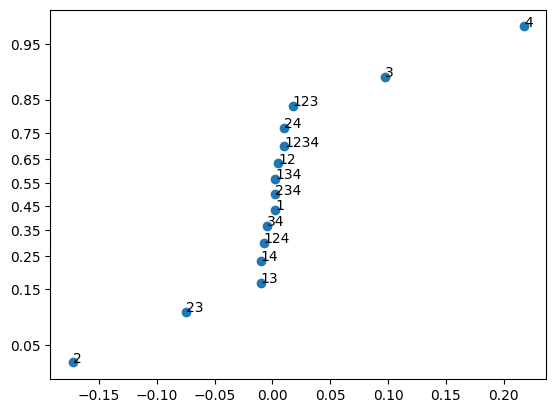

In [123]:
plt.scatter(effects_21['effect'].sort_values(), norm_y_21)
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10).round(2)), np.linspace(0.05,0.95,10).round(2))
[plt.text(x,y,s) for x,y,s in zip(effects_21.sort_values('effect')['effect'], -stats.norm.isf(norm_y_21_pct), effects_21.sort_values('effect')['factor'])]

In [124]:
df_21.groupby(['2','3'])['impurity'].mean()

2   3 
-1  -1    0.4975
     1    0.6700
 1  -1    0.4000
     1    0.4225
Name: impurity, dtype: float64

In [125]:
agitation_21, naoh_21 = np.meshgrid([10,20], [40,45])
naoh_21.flatten(), agitation_21.flatten()

(array([40, 40, 45, 45]), array([10, 20, 10, 20]))

(0.0, 30.0)

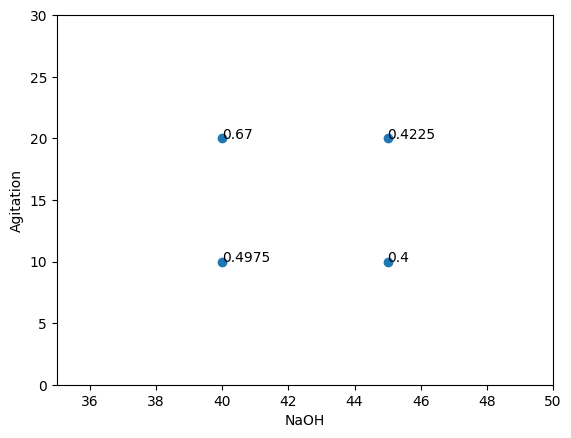

In [126]:
plt.scatter(naoh_21, agitation_21)
[plt.text(x,y,s) for x,y,s in zip(naoh_21.flatten(), agitation_21.flatten(), df_21.groupby(['2','3'])['impurity'].mean().values)]
plt.xlabel('NaOH')
plt.ylabel('Agitation')
plt.xlim(35,50)
plt.ylim(0,30)

### Problem 22

In [127]:
df_22 = pd.DataFrame({
        'A': [(-1)**(i//1+1) for i in range(16)],
    'B': [(-1)**(i//2+1) for i in range(16)],
    'C': [(-1)**(i//4+1) for i in range(16)],
    'D': [(-1)**(i//8+1) for i in range(16)],   
})
df_22['E'] = df_22.prod(axis=1)
df_22['y'] = [14.8,14.5,18.1,19.4,18.4,15.7,27.3,28.2,16.0,15.1,18.9,22.0,19.8,18.9,29.9,27.4]
df_22

,A,B,C,D,E,y
0,-1,-1,-1,-1,1,14.8
1,1,-1,-1,-1,-1,14.5
2,-1,1,-1,-1,-1,18.1
3,1,1,-1,-1,1,19.4
4,-1,-1,1,-1,-1,18.4
5,1,-1,1,-1,1,15.7
6,-1,1,1,-1,1,27.3
7,1,1,1,-1,-1,28.2
8,-1,-1,-1,1,-1,16.0
9,1,-1,-1,1,1,15.1


In [128]:
effects_22 = get_effects([_ for _ in 'ABCD'], df_22, 'y')
effects_22 = pd.DataFrame({
    'factor': effects_22.keys(),
    'effect': effects_22.values()
})
effects_22

,factor,effect
0,A,-0.25
1,B,7.25
2,C,5.85
3,D,1.45
4,AB,0.95
5,AC,-1.05
6,AD,-0.05
7,BC,2.75
8,BD,-0.15
9,CD,0.15


In [129]:
def norm_prob(df, n, effect='effect',factor='factor'):
    y_pct = np.linspace(0,1,n+1)[:-1]+1/(2*n)
    norm_y = -stats.norm.isf(y_pct)
    fig,ax = plt.subplots()
    ax.scatter(df.sort_values(effect)[effect], norm_y)
    [ax.text(x,y,s) for x,y,s in zip(df.sort_values(effect)[effect], norm_y, df.sort_values(effect)[factor])]
    ax.set_yticks(-stats.norm.isf(np.linspace(0.05,0.95,9)), np.linspace(0.05,0.95,9).round(2))
    return fig,ax


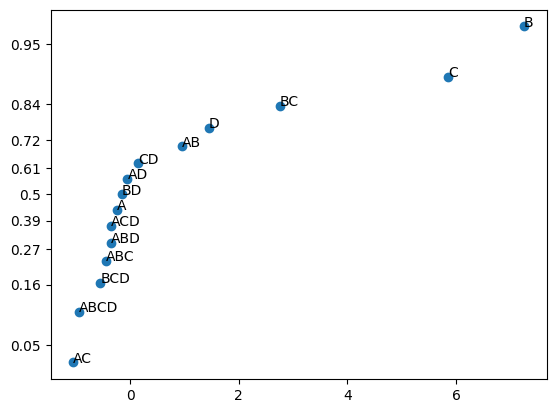

In [130]:
fig_norm_22, ax_norm_22 = norm_prob(effects_22,15)


In [131]:
sig_factors_22 = ['B','C','D','AB','BC']

In [132]:
df_22_residuals = pd.DataFrame()
for sig_factor in sig_factors_22:
    df_22_residuals[sig_factor] = df_22[[_ for _ in sig_factor]].prod(axis=1)

df_22_residuals['residual'] = df_22['y'] - (df_22['y'].mean() + df_22_residuals.T.mul(effects_22[effects_22['factor'].isin(sig_factors_22)].effect.values, axis=0).sum(axis=0)/2)
df_22_residuals.reset_index(inplace=True)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

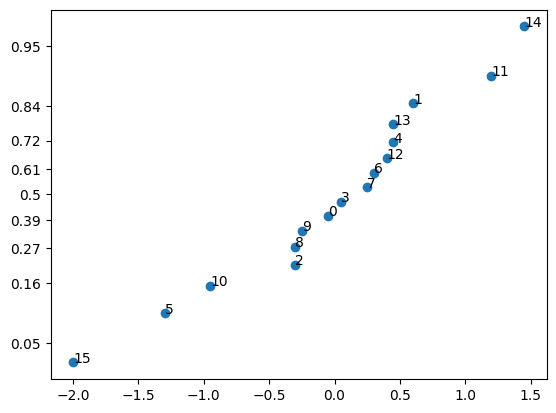

In [133]:
norm_prob(df_22_residuals,16,effect='residual',factor='index')

### Problem 29

In [134]:
df_29 = pd.DataFrame({
    'run_order': [12,1,2,6,15,8,7,4,11,14,3,16,13,10,5,9],
    'x1':[(-1)**(i//1+1) for i in range(16)],
    'x2':[(-1)**(i//2+1) for i in range(16)],
    'x3':[(-1)**(i//4+1) for i in range(16)],
    'x4':[(-1)**(i//8+1) for i in range(16)],

})

df_29['x5'] = df_29.iloc[:,1:].prod(axis=1)
df_29['y1'] = [23.43,25.7,27.75,31.6,23.57,27.68,28.76,31.82,27.09,31.28,31.20,33.42,29.51,31.35,31.16,33.65]
df_29['y2'] = [141.61,161.13,136.54,128.52,145.55,123.75,121.93,120.37,95.24,78.31,74.34,91.76,65.23,78.65,79.76,72.8]
df_29['y3'] = [3318,4141,3790,4061,3431,3425,3507,3765,2580,2450,2319,3067,1925,2466,2485,2450]

df_29

,run_order,x1,x2,x3,x4,x5,y1,y2,y3
0,12,-1,-1,-1,-1,1,23.43,141.61,3318
1,1,1,-1,-1,-1,-1,25.70,161.13,4141
2,2,-1,1,-1,-1,-1,27.75,136.54,3790
3,6,1,1,-1,-1,1,31.60,128.52,4061
4,15,-1,-1,1,-1,-1,23.57,145.55,3431
5,8,1,-1,1,-1,1,27.68,123.75,3425
6,7,-1,1,1,-1,1,28.76,121.93,3507
7,4,1,1,1,-1,-1,31.82,120.37,3765
8,11,-1,-1,-1,1,-1,27.09,95.24,2580
9,14,1,-1,-1,1,1,31.28,78.31,2450


In [135]:
effects_29 = pd.DataFrame()
for result in df_29.columns[-3:]:
    effects = get_effects(list(df_29.columns[1:5]), df_29, result)
    effects_29['factor'] = effects.keys()
    effects_29[result] = effects.values()

effects_29


,factor,y1,y2,y3
0,x1,3.00375,-0.61375,308.75
1,x2,3.71875,-7.93125,213.50
2,x3,0.75375,-12.42625,-284.00
3,x4,3.54375,-55.41375,-1212.00
4,x1x2,-0.09875,0.83375,1.75
5,x1x3,-0.12875,-3.61125,-119.25
6,x1x4,-0.31875,2.35125,-27.75
7,x2x3,-0.39875,3.35125,26.50
8,x2x4,-1.16875,8.23875,11.50
9,x3x4,-0.08375,1.62375,11.50


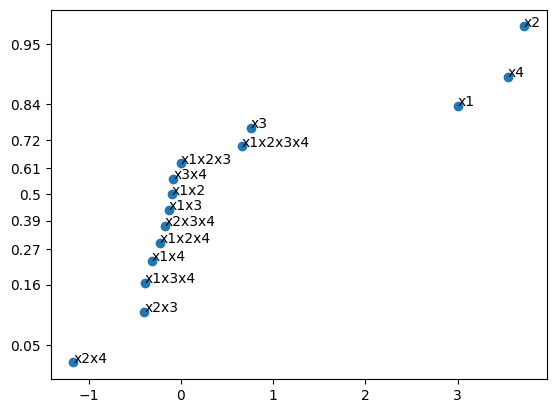

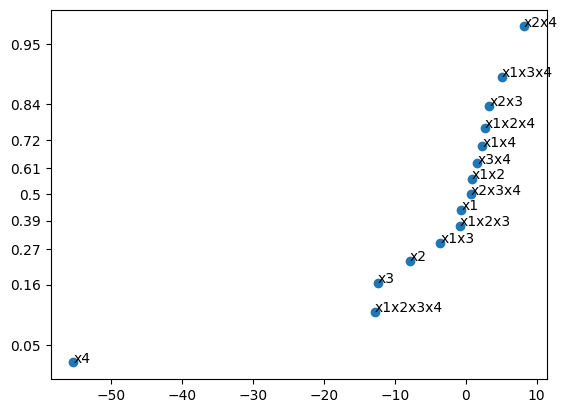

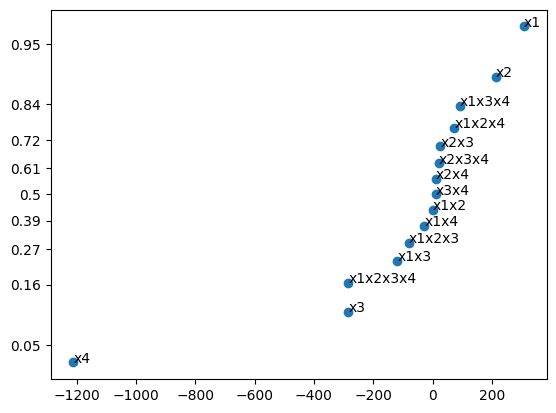

In [136]:
for result in ['y1','y2','y3']:
    norm_prob(effects_29, 15, effect=result)